# Portfolio Analytics: Modern Portfolio Theory (Markowitz)

## ---Data Acquisition & Descriptive Statistics---
>*This section focuses on retrieving historical market data via the Yahoo Finance API. We extract adjusted closing prices for the selected assets to calculate logarithmic returns, providing the necessary statistical foundation for risk modeling.*

In [87]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import numpy as np
import yfinance as yf
import functions_kit as fk

tickers = ['MC.PA', 'SAN.PA', 'AI.PA', 'TTE.PA', 'BNP.PA']
prices_df = yf.download(tickers, start="2021-01-01", end="2026-01-27", auto_adjust=True)['Close']

returns_df = fk.log_returns(prices_df)
returns_df.head()

[*********************100%***********************]  5 of 5 completed

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Ticker,AI.PA,BNP.PA,MC.PA,SAN.PA,TTE.PA
Date,,,,,
2021-01-05,-0.010684,-0.002095,-0.011588,-0.000127,0.025972
2021-01-06,0.002220,0.053748,-0.007734,-0.006095,0.043011
2021-01-07,0.007731,0.022272,0.025552,-0.010113,0.010870
2021-01-08,0.005850,-0.022382,0.019220,0.013673,0.000667
2021-01-11,-0.006951,-0.006758,-0.005536,0.005695,-0.015323


In [88]:
mean_ret, cov_mat, vol_indiv = fk.get_stats(returns_df)

print("--- Annualized expected return ---")
print(mean_ret.sort_values(ascending=False))

print("\n--- Covariance matrix---")
print(cov_mat.head())

print("\n--- Annualized volatilities ---")
print(vol_indiv.sort_values(ascending=False))

--- Annualized expected return ---
Ticker
BNP.PA    0.207686
TTE.PA    0.161703
AI.PA     0.082414
MC.PA     0.043785
SAN.PA    0.040558
dtype: float64

--- Covariance matrix---
Ticker     AI.PA    BNP.PA     MC.PA    SAN.PA    TTE.PA
Ticker                                                  
AI.PA   0.033832  0.019885  0.024938  0.011449  0.011053
BNP.PA  0.019885  0.079989  0.033719  0.012037  0.031624
MC.PA   0.024938  0.033719  0.083950  0.011228  0.019421
SAN.PA  0.011449  0.012037  0.011228  0.052054  0.009228
TTE.PA  0.011053  0.031624  0.019421  0.009228  0.058276

--- Annualized volatilities ---
Ticker
MC.PA     0.289742
BNP.PA    0.282824
TTE.PA    0.241404
SAN.PA    0.228154
AI.PA     0.183936
dtype: float64


## ---Monte Carlo Simulation---
>*In this stage, we employ a Monte Carlo simulation to generate thousands of random weight allocations. For each portfolio, we calculate the expected return and volatility to derive the Sharpe Ratio, allowing us to identify the portfolio with the optimal risk-adjusted performance.*

In [89]:
num_portfolios = 5000
risk_free_rate = 0.02

print(f"Generating {num_portfolios} portfolios... please wait.")

results, weights_record = fk.simulate_portfolios(mean_ret,
                                                 cov_mat,
                                                 num_portfolios=num_portfolios)
print (f"Simulation complete. Data is ready in memory.results shape: {results.shape}")

Generating 5000 portfolios... please wait.
Simulation complete. Data is ready in memory.results shape: (5000, 3)


## ---Portfolio Optimization & Capital Market Line (CML)---
>*The final visualization integrates the Capital Market Line (CML) with the efficient frontier scatter plot. This graph illustrates the theoretical transition from the risk-free asset to the optimal market portfolio within the Markowitz framework.*

--- CML & TANGENCY PORTFOLIO ---
Risk Free Rate: 2.00%
Expected Annual Return: 17.41%
Annual Volatility:      21.23%
Sharpe Ratio:           0.73
----------------------------------------
---OPTIMAL ASSET ALLOCATION---
MC.PA  :   5.86%
SAN.PA :  46.76%
AI.PA  :   3.15%
TTE.PA :   0.65%
BNP.PA :  43.59%


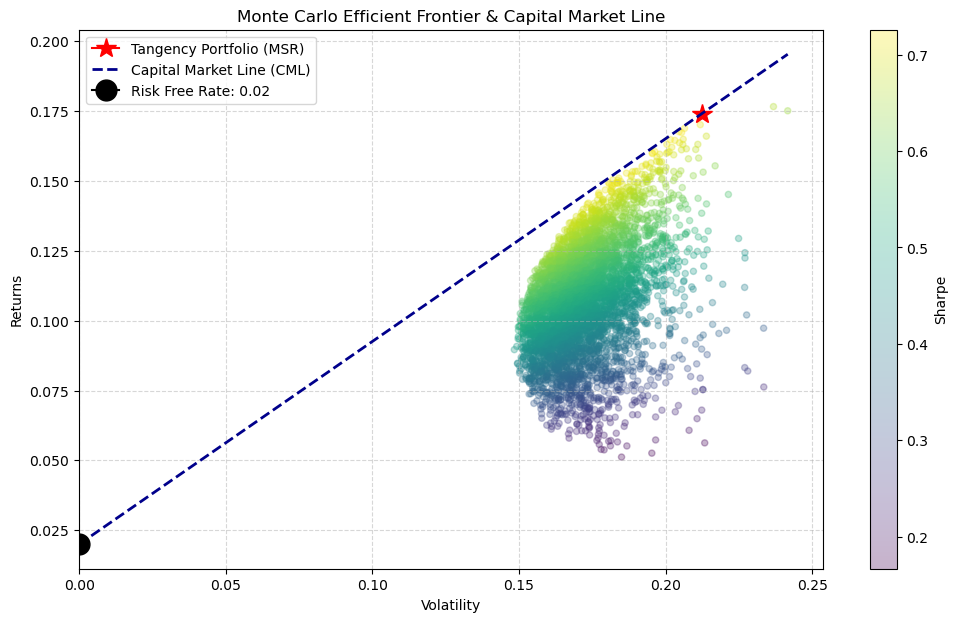

In [90]:
#Generate the Efficient Frontier plot
fk.plot_mc_ef(results,
              risk_free_rate=risk_free_rate
             )

#Convert simulation results into a DataFrame
results_df = pd.DataFrame(results, columns=["Returns", "Volatility", "Sharpe"])

#Identify the Max Sharpe Ratio (MSR) portfolio
msr_idx = results_df["Sharpe"].idxmax()
msr_portfolio = results_df.loc[msr_idx]

#Display performance metrics
print("--- CML & TANGENCY PORTFOLIO ---")
print(f"Risk Free Rate: {risk_free_rate:.2%}")
print(f"Expected Annual Return: {msr_portfolio['Returns']:.2%}")
print(f"Annual Volatility:      {msr_portfolio['Volatility']:.2%}")
print(f"Sharpe Ratio:           {msr_portfolio['Sharpe']:.2f}")
print("-"*40)

#Display the optimal weight distribution (Allocation)
print("---OPTIMAL ASSET ALLOCATION---")
for ticker, weight in zip(tickers, weights_record[msr_idx]):
    print(f"{ticker:7}: {weight:7.2%}")

#### Critical Analysis & Real-World Limitations:
>*While the Capital Market Line (CML) and the Markowitz Efficient Frontier provide a robust theoretical framework for portfolio optimization, several limitations hinder their effectiveness in real-world trading.*

#### Estimation Risk (The "Garbage In, Garbage Out" problem):
>*The model is highly sensitive to input parameters. Expected returns and volatilities are calculated based on historical data, which is rarely a reliable predictor of future performance.*

#### Static Nature of Correlations: 
>*The model assumes that correlations between assets remain constant. In reality, during market crashes, correlations often spike toward 1, neutralizing the benefits of diversification when it is needed most.*

#### Normal Distribution Assumption:
>*Markowitz theory assumes that asset returns follow a normal distribution (Bell Curve). However, real markets exhibit "Fat Tails" (Black Swan events) and skewness, meaning extreme losses occur more frequently than the model predicts.*

#### Market Frictions: 
>*The CML assumes that investors can borrow and lend at the same risk-free rate (€STR) without limit, and ignores transaction costs, taxes, and liquidity constraints that significantly erode real-world returns.*

#### Conclusion: 
>*This simulation serves as a strategic compass for asset allocation but should be used with caution. It represents a "perfect world" scenario that must be adjusted for market volatility and non-linear risks. While the Markowitz model identifies the most efficient portfolio based on historical data, the actual performance will depend on the stability of correlations and the absence of extreme market events (Black Swans).*
